In [ ]:
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchsummary import summary

from M2.DP import DPForwardSolver
from M2.PINN.model import AcousticPINN, g
from M2.PINN.loss import loss_fn
from M2.PINN.training import train_pinn
from M2.NN.model import Neural_Network, NNForwardSolver
from M2.NN.training import train_nn
from M2.inverse_problem import inverse_function
from M2.Utils.dataset import make_dataset, make_inverse_dataset
from M2.Utils.visualization import plot_seimograms, plot_epicenters, check_seismograms
from M2.Utils.source import source

from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# device = "mps"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
device = "cpu"
sensors = torch.tensor([[-0.9, -0.2],
                        [ 0.6,  0.8]], dtype=torch.float32, device=device)
                        
e_true = (0.25, -0.10)

dp_forward_solver = DPForwardSolver(sensors=sensors,
    c=1, x_min=-1, x_max=1, y_min=-1, y_max=1,
    Nx=101, Ny=101, Nt=401, T=2,
    A=5, t0=0.1, f0=10, gamma=50, device=device)

Nt = dp_forward_solver.Nt
T = dp_forward_solver.T

with torch.no_grad():
    traces_obs = dp_forward_solver.forward(*e_true)


In [66]:
e_hat_dp, traces_dp, _, history = inverse_function(
    forward=dp_forward_solver,
    traces_obs=traces_obs.cpu(),
    dt=dp_forward_solver.dt,
    t_star=0.0,
    init=(0.0, 0.0),
    steps=50,
    lr=1,
    lam=1e-6,
    device=device,
)


  0%|          | 0/50 [00:00<?, ?it/s]

In [38]:
pinn = train_pinn(epochs=10000, dt=dp_forward_solver.dt, h=dp_forward_solver.h, Nt = dp_forward_solver.Nt,
 c=dp_forward_solver.c, lr=1e-5, device=device)

pinn_forward = PinnForwardSolver(
    model=pinn,                
    sensors=sensors,
    x_min=-1, x_max=1,
    y_min=-1, y_max=1,
    Nx=101, Ny=101,
    Nt=Nt,
    dt=dp_forward_solver.dt,
    h=dp_forward_solver.h,
    c=dp_forward_solver.c,
    device=device,
)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [39]:
e_hat_pinn, traces_pinn, _ = inverse_function(
    forward=pinn_forward,
    traces_obs=traces_obs,
    dt=pinn_forward.dt,
    t_star=0.0,
    init=(0.0, 0.0),
    steps=50,
    lr=1,
    lam=1e-6,
    # lr=0.2,
    # lam=1e-3
)

  0%|          | 0/50 [00:00<?, ?it/s]

In [40]:
summary(pinn, input_size=(3, 101, 101))

Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            28
Total params: 28
Trainable params: 28
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            28
Total params: 28
Trainable params: 28
Non-trainable params: 0

In [ ]:
model_ml = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)

# # datset for direct inversion -> learn (e_x,e_y) from seismograms
Xinv, yinv = make_inverse_dataset(dp_forward_solver, n_epicenters=256)
Xtr_inv, Xte_inv, ytr_inv, yte_inv = train_test_split(Xinv, yinv, test_size=0.15, random_state=42)


model_ml = MultiOutputRegressor(model_ml, n_jobs=-1)
model_ml.fit(Xtr_inv, ytr_inv)
pred_ml = model_ml.predict(Xte_inv)
e_hat_ml = model_ml.predict(traces_obs.reshape(1, -1))[0]

In [ ]:
# Dataset for surrogate forward solver to learn u(x,y,t) from simulations :
X, y = make_dataset(dp_forward_solver, n_epicenters=256, n_points_per_epi=1024)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.15, random_state=42)


neural_network = Neural_Network(width=256, depth=5).to(device)

# normalize
X_mean = Xtr.mean(axis=0)
X_std  = Xtr.std(axis=0) + 1e-12
y_mean = ytr.mean()
y_std  = ytr.std() + 1e-12

Xtr_n = (Xtr - X_mean) / X_std
Xte_n = (Xte - X_mean) / X_std
ytr_n = (ytr - y_mean) / y_std
yte_n = (yte - y_mean) / y_std

# train supervised on the dataset generated from DP traces
neural_network = train_nn(neural_network, Xtr_n, ytr_n, epochs=200, batch_size=4096, lr=1e-3)

forward_nn = NNForwardSolver(neural_network, sensors, Nt, dp_forward_solver.T, device, X_mean, X_std, y_mean, y_std)


mse=1.593e-08: 100%|██████████| 100/100 [04:06<00:00,  2.46s/it]


In [ ]:
e_hat_nn, traces_nn, _ = inverse_function(
    forward=forward_nn,
    traces_obs=traces_obs,
    dt=dp_forward_solver.dt,
    t_star=0.0,
    init=(0.0, 0.0),
    steps=50,
    lr=1,
    lam=1e-6,
    device="cpu",
)

100%|██████████| 50/50 [00:07<00:00,  6.51it/s]


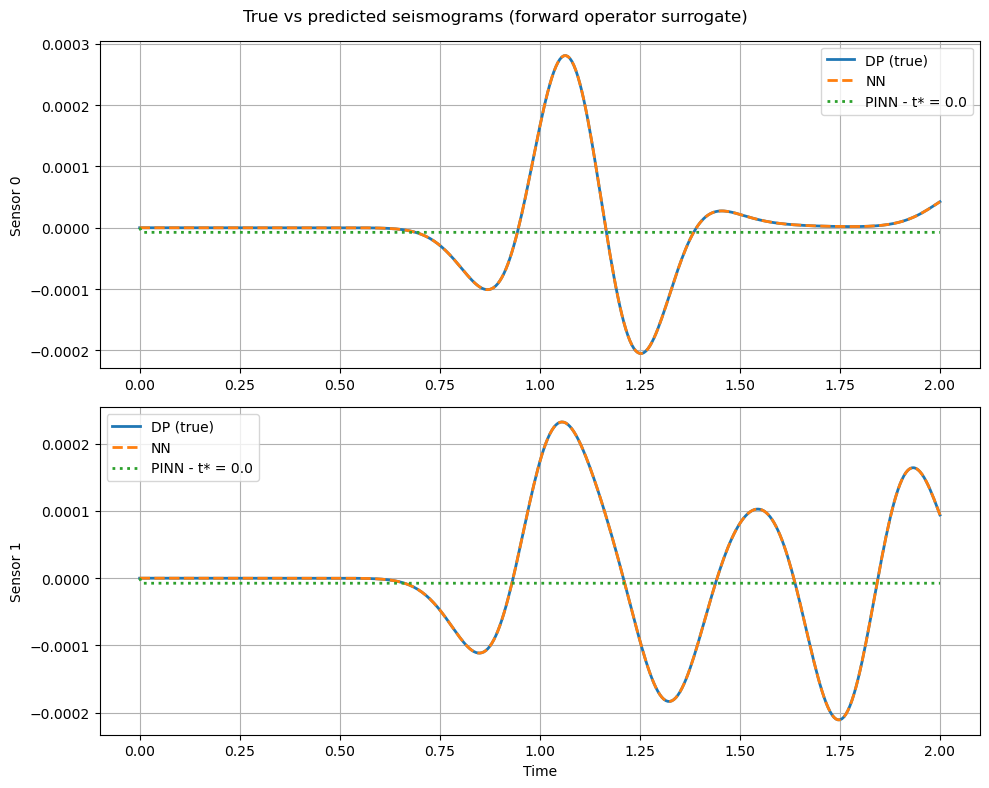

Using different forward solver as surrogate :
True epicenter : (0.25, -0.1)
DP : (0.25000008940696716, -0.10000009834766388)
PINN :  (0.0, 0.0)


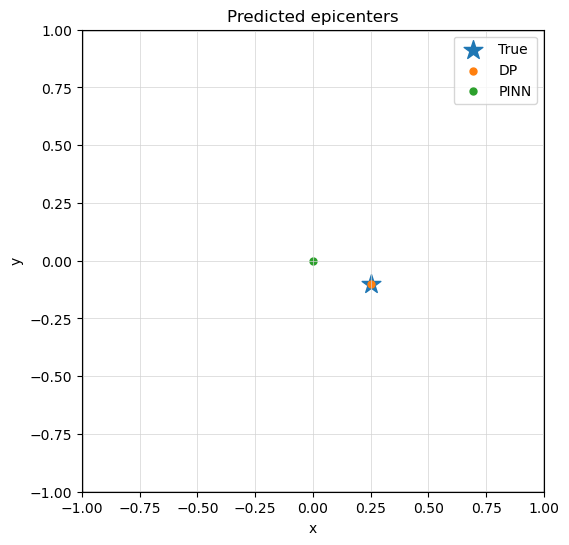

In [41]:
# plot_seimograms(traces_obs,traces_nn, traces_pinn, T, Nt)
# plot_seimograms(traces_obs,traces_obs, traces_obs, T, Nt)
plot_seimograms(traces_obs,traces_obs, traces_pinn, T, Nt)


print('Using different forward solver as surrogate :')
print("True epicenter :", e_true)
print("DP :", (float(e_hat_dp[0]), float(e_hat_dp[1])))
# print("NN : ",(float(e_hat_nn[0]), float(e_hat_nn[1])))
print("PINN : ",(float(e_hat_pinn[0]), float(e_hat_pinn[1])))
plot_epicenters(
    e_true=e_true,
    e_hat_dp=(e_hat_dp[0], e_hat_dp[1]),
    # e_hat_nn=(e_hat_nn[0], e_hat_nn[1]),
    e_hat_pinn=(e_hat_pinn[0], e_hat_pinn[1]),
)